# Mie calculation for droplets in GFAS opening angles
Here, theoretical scattering cross sections for the GFAS are being calculated for different refractive indices

author: Lea Haberstock, Stockholm University, Department of Environmental Science, Atmospheric Unit \
developed toether with: Darrel Baumgardner and Paul Zieger

contact: lea.haberstock@aces.su.se \
used in publication: Haberstock et al. 2026 (submitted to AMT) 


Last modified June 01/07/2026

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import PyMieScatt  as pms
import pandas as pd
import matplotlib as mpl
import matplotlib.gridspec as gridspec

### Forward and back scattering cross sections GFAS 
wavelength = 660 nm \
opening angles
- backward 168-176.5 deg
- forward 3.8-20 deg

In [ ]:
## P pol and Spol scattering cross section vs Dp for different diameters
def sct_SLSR(m, diam, wvl, ang):
    ''' 
    calculate the scattering cross section for an array of diameters. It calculates the scattering cross section for 30 steps between min and maximum opening angle integrates over the opening angle
    
    m: refractive index as a single value (complex or natural)
    diam: array of diameters
    wvl: wavelength of the incident light
    ang: array of scattering angle with a minimum of two values, the min and the max opening angle
    '''
    sc_L = np.full((len(diam)), np.nan)  # output vector
    sc_R = np.full((len(diam)), np.nan)  # output vector
    sc_TOT = np.full((len(diam)), np.nan)  # output vector
    angle_res = (ang[-1]-ang[0])/30
    for k1, d in enumerate(diam):
        x = d * np.pi / wvl  # size parameter
        theta, SL, SR, SU = pms.ScatteringFunction(m=m, wavelength=wvl, diameter=d, nMedium=1.0,  minAngle=ang[0], maxAngle=ang[-1], angularResolution= angle_res)
        sc_l = x ** (-2) * np.trapz((SL) * np.sin(theta), theta)
        sc_r = x ** (-2) * np.trapz((SR) * np.sin(theta), theta)
        sc_tot =x ** (-2) * np.trapz((SL+SR) * np.sin(theta), theta)
        sc_L[k1] = sc_l * 0.25 * np.pi * (d * 1e-9) ** 2
        sc_R[k1] = sc_r * 0.25 * np.pi * (d * 1e-9) ** 2
        sc_TOT[k1] = sc_tot * 0.25 * np.pi * (d * 1e-9) **2
        sc_L = sc_L 
        sc_R = sc_R 
        sc_TOT = sc_TOT 
    return sc_L, sc_R, sc_TOT

### real part

In [ ]:
diam = np.linspace(0.7, 50, 200) * 1000  # particle diameter in nm
wvl = 660  # laser wavelength in nm

# change real part of refractive index from 1.33 to 1.6
r =  np.linspace(1.33, 1.6, 25)

# make stoff a list of r not as values but as words
stoff = [str(i) for i in r]

ang_bw = np.linspace(168, 176.5, 30) # backscattering opening angles should be around 168 - 176 degrees
ang_fw = np.linspace(3.8, 20, 30) 

L_R004 = {} # forward scattering
L_R168 = {} # backscattering


# loop over the refractive indices and calculate the scattering cross sections
for i in range((len(stoff))):
    sc_L, sc_R, sc_tot = sct_SLSR(r[i], diam, wvl, ang_bw)
    L_R168[stoff[i]] = [sc_L, sc_R, sc_tot]
    sc_L, sc_R, sc_tot = sct_SLSR(r[i], diam, wvl, ang_fw)
    L_R004[stoff[i]] = [sc_L, sc_R, sc_tot]

# make one for just water
sc_L, sc_R, sc_tot = sct_SLSR(1.33+0j, diam, wvl, ang_bw)
water_bw = [sc_L, sc_R, sc_tot]
sc_L, sc_R, sc_tot = sct_SLSR(1.33+0j, diam, wvl, ang_fw)
water_fw = [sc_L, sc_R, sc_tot]

# smooth data 
for i in range((len(stoff))):
    L_R168[stoff[i]][0] = pd.Series(L_R168[stoff[i]][0]).rolling(3).mean()
    L_R168[stoff[i]][1] = pd.Series(L_R168[stoff[i]][1]).rolling(3).mean()
    L_R168[stoff[i]][2] = pd.Series(L_R168[stoff[i]][2]).rolling(3).mean()
    L_R004[stoff[i]][2] = pd.Series(L_R004[stoff[i]][2]).rolling(3).mean()
water_bw[0] = pd.Series(water_bw[0]).rolling(3).mean()
water_bw[1] = pd.Series(water_bw[1]).rolling(3).mean()
water_fw[2] = pd.Series(water_fw[2]).rolling(3).mean()


In [77]:
mpl.rcParams.update({
    "font.size": 12,          # base size
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 12,
})

/tmp/ipykernel_1968842/3305838970.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar


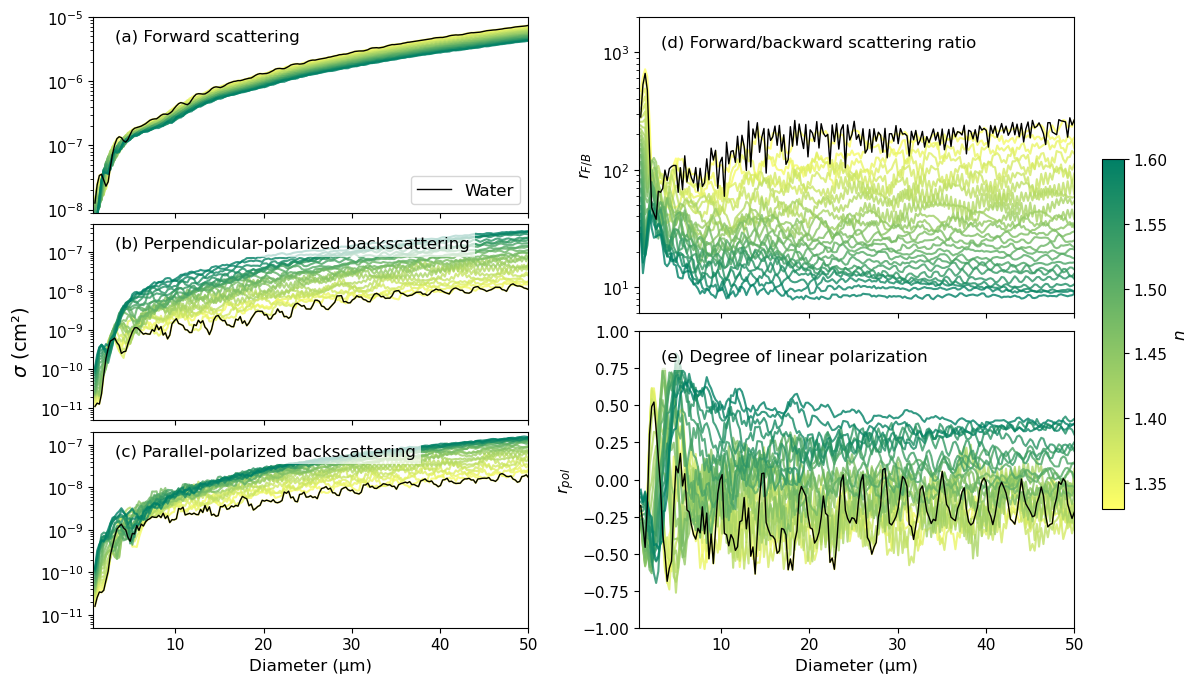

In [ ]:
diam = np.linspace(0.4, 50, 200) * 1000  # particle diameter in nm
wvl = 660  # laser wavelength in nm

# change real part of refractive index from 1.33 to 1.6
r =  np.linspace(1.33, 1.6, 25)

# make stoff a list of r not as values but as words
stoff = [str(i) for i in r]

# colormap
c = plt.cm.summer_r(np.linspace(0, 1, len(stoff)))

fig = plt.figure(figsize=(12, 7))

# main 2x2 grid
gs = gridspec.GridSpec(2, 2, figure=fig, width_ratios=[1, 1])

# left column: subdivide into 3 rows
gs_left = gs[:, 0].subgridspec(3, 1)
ax1 = fig.add_subplot(gs_left[0, 0])
ax4 = fig.add_subplot(gs_left[1, 0])
ax5 = fig.add_subplot(gs_left[2, 0])

# right column: subdivide into 2 rows
gs_right = gs[:, 1].subgridspec(2, 1)
ax2 = fig.add_subplot(gs_right[0, 0])
ax3 = fig.add_subplot(gs_right[1, 0])

# ----------------- plotting loop -----------------
for i in range(len(stoff)):
    ax1.plot(diam / 1000, L_R004[stoff[i]][2]*1e4, alpha=0.8, c=c[i])  # forward scattering
    ax2.plot(diam / 1000, L_R004[stoff[i]][2]/L_R168[stoff[i]][2], alpha=0.8, c=c[i])  # F/B ratio
    ax3.plot(diam / 1000, (L_R168[stoff[i]][0]-L_R168[stoff[i]][1]) /
             (L_R168[stoff[i]][0] + L_R168[stoff[i]][1]), alpha=0.8, c=c[i])  # polarization ratio
    ax4.plot(diam / 1000, L_R168[stoff[i]][0]*1e4, alpha=0.8, c=c[i])  # S-pol
    ax5.plot(diam / 1000, L_R168[stoff[i]][1]*1e4, alpha=0.8, c=c[i])  # P-pol

# Water reference curves
ax1.plot(diam/1000, water_fw[2]*1e4, label='Water', color='black', lw=1)
ax2.plot(diam/1000, water_fw[2]/water_bw[2], label='Water', color='black', lw=1)
ax3.plot(diam/1000, (water_bw[0]-water_bw[1])/(water_bw[0]+water_bw[1]), label='Water', color='black', lw=1)
ax4.plot(diam/1000, water_bw[0]*1e4, label='Water', color='black', lw=1)
ax5.plot(diam/1000, water_bw[1]*1e4, label='Water', color='black', lw=1)

# scales
for axs in [ax1, ax2, ax4, ax5]:
    axs.set(yscale='log')
# remove xtick labels for upper left column
for ax in (ax1, ax2, ax4):
    ax.tick_params(axis='x', which='both', bottom=True, labelbottom=False)


# labels
# merge the ylabels of ax1, ax4 and ax5
for ax in (ax1, ax4, ax5):
    ax.set_ylabel("")  # clear their individual labels
fig.text(-0.01, 0.5, "$\sigma$ (cm²)", rotation="vertical", va="center", fontsize=14)

ax1.legend(loc='lower right', fontsize=12)
ax2.set_ylabel('$r_{F/B}$', fontsize=12)
ax3.set_ylabel('$r_{pol}$', fontsize=12)
ax3.set_xlabel('Diameter (µm)', fontsize=12)
ax5.set_xlabel('Diameter (µm)', fontsize=12)

ax1.set(ylim = (9*10**-9,10**-5), xlim = (0.7,50))
ax2.set(ylim = (6, 2000), xlim = (0.7,50))
ax3.set(ylim=(-1, 1), xlim = (0.7,50))
ax4.set(ylim = (5*10**-12,5*10**-7), xlim = (0.7,50))
ax5.set(ylim = (5*10**-12,2*10**-7), xlim = (0.7,50))


# colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.summer_r, norm=plt.Normalize(vmin=r[0], vmax=r[-1]))
dax = fig.add_axes([0.9, 0.26, 0.018, 0.5])
cbar = plt.colorbar(sm, cax=dax)
cbar.set_label('$n$', fontsize=12)

# panel labels
ax1.text(0.05, 0.94, '(a) Forward scattering', transform=ax1.transAxes, fontsize=12, va='top', ha='left', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax2.text(0.05, 0.94, '(d) Forward/backward scattering ratio', transform=ax2.transAxes, fontsize=12, va='top', ha='left', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax4.text(0.05, 0.94, '(b) Perpendicular-polarized backscattering', transform=ax4.transAxes, fontsize=12, va='top', ha='left', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax5.text(0.05, 0.94, '(c) Parallel-polarized backscattering', transform=ax5.transAxes, fontsize=12, va='top', ha='left', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax3.text(0.05, 0.94, '(e) Degree of linear polarization', transform=ax3.transAxes, fontsize=12, va='top', ha='left', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar
#plt.savefig('modeled_scatt_cross.png', dpi=300, bbox_inches='tight')
plt.show()


##### imaginary part

In [79]:

diam = np.linspace(0.4, 50, 200) * 1000  # particle diameter in nm
wvl = 660  # laser wavelength in nm

# make array with complex refractive indices of 1.33 with i = 0-0.02
r = 1.33 + 0j + 0.02j * np.linspace(0, 1, 21)
# make stoff a list of r not as values but as words
stoff = [str(i) for i in r]

ang_bw = np.linspace(168, 176.5, 30) # backscattering opening angles should be around 168 - 176 degrees
ang_fw = np.linspace(3.8, 20, 30) 

iL_R004 = {} # forward scattering
iL_R168 = {} # backscattering

for i in range((len(stoff))):
    sc_L, sc_R, sc_tot = sct_SLSR(r[i], diam, wvl, ang_bw)
    iL_R168[stoff[i]] = [sc_L, sc_R, sc_tot]
    sc_L, sc_R, sc_tot = sct_SLSR(r[i], diam, wvl, ang_fw)
    iL_R004[stoff[i]] = [sc_L, sc_R, sc_tot]

# make one for just water
sc_L, sc_R, sc_tot = sct_SLSR(1.33+0j, diam, wvl, ang_bw)
iwater_bw = [sc_L, sc_R, sc_tot]
sc_L, sc_R, sc_tot = sct_SLSR(1.33+0j, diam, wvl, ang_fw)
iwater_fw = [sc_L, sc_R, sc_tot]

# smooth data 
for i in range((len(stoff))):
    iL_R168[stoff[i]][0] = pd.Series(iL_R168[stoff[i]][0]).rolling(3).mean()
    iL_R168[stoff[i]][1] = pd.Series(iL_R168[stoff[i]][1]).rolling(3).mean()
    iL_R168[stoff[i]][2] = pd.Series(iL_R168[stoff[i]][2]).rolling(3).mean()
    iL_R004[stoff[i]][2] = pd.Series(iL_R004[stoff[i]][2]).rolling(3).mean()
iwater_bw[0] = pd.Series(iwater_bw[0]).rolling(3).mean()
iwater_bw[1] = pd.Series(iwater_bw[1]).rolling(3).mean()
iwater_fw[2] = pd.Series(iwater_fw[2]).rolling(3).mean()


/tmp/ipykernel_1968842/1613353587.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar


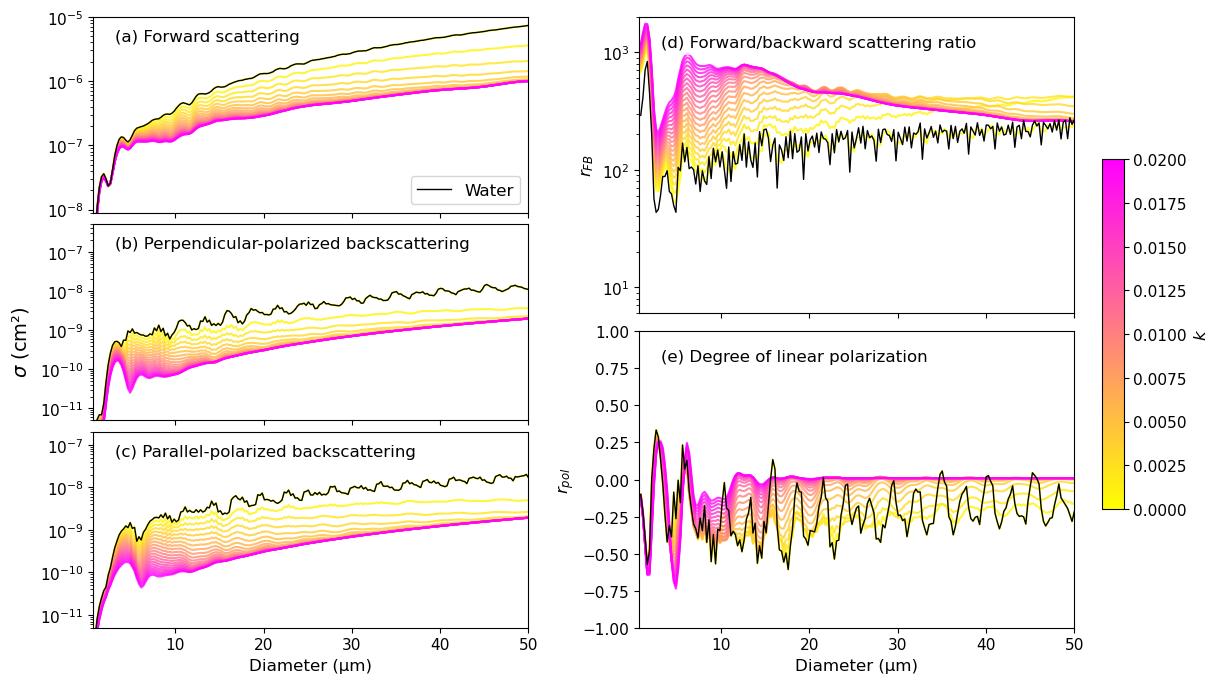

In [ ]:

diam = np.linspace(0.4, 50, 200) * 1000  # particle diameter in nm
wvl = 660  # laser wavelength in nm


# make array with complex refractive indices of 1.33 with i = 0-0.02
r = 1.33 + 0j + 0.02j * np.linspace(0, 1, 21)
# make stoff a list of r not as values but as words
stoff = [str(i) for i in r]

import matplotlib.gridspec as gridspec


# colormap
c = plt.cm.spring_r(np.linspace(0, 1, len(stoff)))

fig = plt.figure(figsize=(12, 7))

# main 2x2 grid
gs = gridspec.GridSpec(2, 2, figure=fig, width_ratios=[1, 1])

# left column: subdivide into 3 rows
gs_left = gs[:, 0].subgridspec(3, 1)
ax1 = fig.add_subplot(gs_left[0, 0]) # forward
ax4 = fig.add_subplot(gs_left[1, 0]) # S-pol
ax5 = fig.add_subplot(gs_left[2, 0]) # P-pol

# right column: subdivide into 2 rows
gs_right = gs[:, 1].subgridspec(2, 1)
ax2 = fig.add_subplot(gs_right[0, 0]) # F/B
ax3 = fig.add_subplot(gs_right[1, 0]) # rpol

# ----------------- plotting loop -----------------
for i in range(len(stoff)):
    ax1.plot(diam / 1000, iL_R004[stoff[i]][2]*1e4, alpha=0.8, c=c[i])  # forward scattering
    ax2.plot(diam / 1000, iL_R004[stoff[i]][2]/iL_R168[stoff[i]][2], alpha=0.8, c=c[i])  # F/B ratio
    ax3.plot(diam / 1000, (iL_R168[stoff[i]][0]-iL_R168[stoff[i]][1]) /
             (iL_R168[stoff[i]][0] + iL_R168[stoff[i]][1]), alpha=0.8, c=c[i])  # polarization ratio
    ax4.plot(diam / 1000, iL_R168[stoff[i]][0]*1e4, alpha=0.8, c=c[i])  # S-pol
    ax5.plot(diam / 1000, iL_R168[stoff[i]][1]*1e4, alpha=0.8, c=c[i])  # P-pol

# Water reference curves
ax1.plot(diam/1000, iwater_fw[2]*1e4, label='Water', color='black', lw=1)
ax2.plot(diam/1000, iwater_fw[2]/iwater_bw[2], label='Water', color='black', lw=1)
ax3.plot(diam/1000, (iwater_bw[0]-iwater_bw[1])/(iwater_bw[0]+iwater_bw[1]), label='Water', color='black', lw=1)
ax4.plot(diam/1000, iwater_bw[0]*1e4, label='Water', color='black', lw=1)
ax5.plot(diam/1000, iwater_bw[1]*1e4, label='Water', color='black', lw=1)

# scales
for axs in [ax1, ax2, ax4, ax5]:
    axs.set(yscale='log')
# remove xtick labels for upper left column
for ax in (ax1, ax2, ax4):
    ax.tick_params(axis='x', which='both', bottom=True, labelbottom=False)


# labels
# merge the ylabels of ax1, ax4 and ax5
for ax in (ax1, ax4, ax5):
    ax.set_ylabel("")  # clear their individual labels
fig.text(-0.01, 0.5, "$\sigma$ (cm²)", rotation="vertical", va="center", fontsize=14)

ax1.legend(loc='lower right', fontsize=12)
ax2.set_ylabel('$r_{FB}$', fontsize=12)
ax3.set_ylabel('$r_{pol}$', fontsize=12)
ax3.set_xlabel('Diameter (µm)', fontsize=12)

ax5.set_xlabel('Diameter (µm)', fontsize=12)

ax1.set(ylim = (9*10**-9,10**-5), xlim = (0.7,50))
ax2.set(ylim = (6, 2000), xlim = (0.7,50))
ax3.set(ylim=(-1, 1), xlim = (0.7,50))
ax4.set(ylim = (5*10**-12,5*10**-7), xlim = (0.7,50))
ax5.set(ylim = (5*10**-12,2*10**-7), xlim = (0.7,50))

# colorbar
imaginary_part = np.linspace(0, 0.02, 21)
sm = plt.cm.ScalarMappable(cmap=plt.cm.spring_r, norm=plt.Normalize(vmin=imaginary_part[0], vmax=imaginary_part[-1]))
dax = fig.add_axes([0.9, 0.26, 0.018, 0.5])
cbar = plt.colorbar(sm, cax=dax)
cbar.set_label('$k$', fontsize=12)

# panel labels
ax1.text(0.05, 0.94, '(a) Forward scattering', transform=ax1.transAxes, fontsize=12,
         va='top', ha='left', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax2.text(0.05, 0.94, '(d) Forward/backward scattering ratio', transform=ax2.transAxes, fontsize=12,
         va='top', ha='left', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax4.text(0.05, 0.94, '(b) Perpendicular-polarized backscattering', transform=ax4.transAxes, fontsize=12,
         va='top', ha='left', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax5.text(0.05, 0.94, '(c) Parallel-polarized backscattering', transform=ax5.transAxes, fontsize=12,
         va='top', ha='left', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax3.text(0.05, 0.94, '(e) Degree of linear polarization', transform=ax3.transAxes, fontsize=12,
         va='top', ha='left', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar
#plt.savefig('model_scatt_cross_imaginary.png', dpi=300, bbox_inches='tight')
plt.show()
